In [1]:
# Basic libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# AdaBoost model
from sklearn.ensemble import AdaBoostClassifier

# Preprocessing
from sklearn.preprocessing import LabelEncoder

In [2]:
# Loading dataset 
df = pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\Downloads\Titanic-Dataset.csv")

# Display first 5 rows to understand structure
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Checking dataset shape (rows, columns)
print("Shape of dataset:", df.shape)
print("\n-----------------------------------------------------------------------")
# Checking column names and data types
df.info()
print("\n-----------------------------------------------------------------------")
# Checking missing values
df.isnull().sum()

Shape of dataset: (891, 12)

-----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

-----------------------------------------------------------------------


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Filling missing Age values with median (better than mean for skewed data)
df['Age']=df['Age'].fillna(df['Age'].median())

In [8]:
# Filling Embarked with most frequent value
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
# Dropping Cabin column because too many missing values
df.drop(columns=['Cabin'], inplace=True)

In [10]:
# Dropping irrelevant columns (these don't help model learning)
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# Convert categorical variables into numerical form
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [11]:
# X = input features
X = df.drop('Survived', axis=1)

# y = target variable
y = df['Survived']

In [12]:
# Splitting data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Checking shapes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [13]:
# Creating AdaBoost model
# n_estimators = number of weak learners (decision stumps)
model = AdaBoostClassifier(
    n_estimators=100,   # number of trees
    learning_rate=1.0,  # contribution of each model
    random_state=42
)

# Training the model
model.fit(X_train, y_train)

C:\Users\Chinmay Pratap Dalvi\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=100, random_state=42)

In [14]:
# Predicting on test data
y_pred = model.predict(X_test)

Accuracy: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



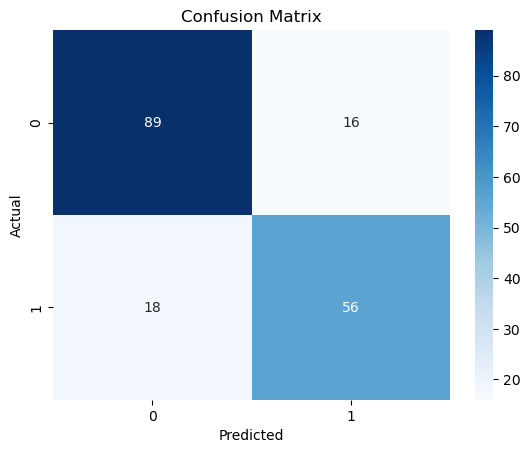

In [15]:
# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report (precision, recall, f1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizing confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

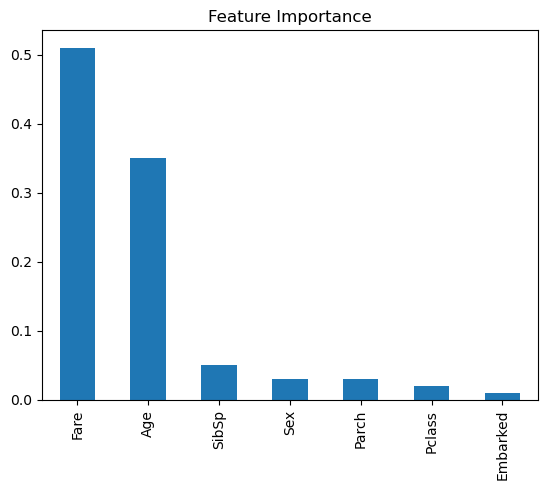

In [16]:
# Checking which features are most important
importance = pd.Series(model.feature_importances_, index=X.columns)

# Sorting values
importance = importance.sort_values(ascending=False)

# Plotting
importance.plot(kind='bar', title="Feature Importance")
plt.show()